In [2]:
!pip install -q mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 86.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [3]:
import mne
import numpy as np
import matplotlib.pyplot as plt

print("MNE Version:", mne.__version__)

MNE Version: 1.12.1


##DataSet

In [4]:
sample_data_folder = mne.datasets.sample.data_path()

print(sample_data_folder)

Using default location ~/mne_data for sample...
Creating /root/mne_data
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m34s (1576.2 MB)
/root/mne_data/MNE-sample-data


In [5]:
sample_data_folder = mne.datasets.sample.data_path()

print(sample_data_folder)

/root/mne_data/MNE-sample-data


In [6]:
from pathlib import Path

sample_data_folder = Path(sample_data_folder)

for file in sample_data_folder.rglob("*"):
    print(file)

/root/mne_data/MNE-sample-data/version.txt
/root/mne_data/MNE-sample-data/MEG
/root/mne_data/MNE-sample-data/subjects
/root/mne_data/MNE-sample-data/SSS
/root/mne_data/MNE-sample-data/MEG/sample
/root/mne_data/MNE-sample-data/subjects/sample
/root/mne_data/MNE-sample-data/subjects/morph-maps
/root/mne_data/MNE-sample-data/subjects/fsaverage_sym
/root/mne_data/MNE-sample-data/subjects/fsaverage
/root/mne_data/MNE-sample-data/SSS/ct_sparse_mgh.fif
/root/mne_data/MNE-sample-data/SSS/sss_cal_mgh.dat
/root/mne_data/MNE-sample-data/MEG/sample/fsaverage_audvis-eeg-rh.stc
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-mag-oct-6-fwd-sensmap-3-lh.w
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-vol-7-fwd.fif
/root/mne_data/MNE-sample-data/MEG/sample/audvis.ave
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-eeg-oct-6-fwd-sensmap-6-rh.w
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-grad-oct-6-f

In [13]:
raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_trunc_raw.fif"

print(raw_file)

/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_trunc_raw.fif


In [11]:
import os

for root, dirs, files in os.walk("/root/mne_data"):
    for file in files:
        if file.endswith(".fif"):
            print(os.path.join(root, file))

/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-vol-7-fwd.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw-eve.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-eeg-oct-6-meg-eeg-diagnoise-inv.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-no-filter-ave.fif
/root/mne_data/MNE-sample-data/MEG/sample/all-trans.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
/root/mne_data/MNE-sample-data/MEG/sample/ernoise_raw-eve.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-oct-6-meg-diagnoise-inv.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-eeg-oct-6-meg-eeg-inv.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-eeg-oct-6-fwd.fif
/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis-shrunk-cov.fif
/root/mne_data/MNE-sample-data/MEG/sample/s

##Loading EEg

In [15]:
import mne

file_path = "/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif"

raw = mne.io.read_raw_fif(
    file_path,
    preload=True
)

print(raw)

Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>


In [16]:
print("Sampling Frequency:", raw.info["sfreq"], "Hz")

Sampling Frequency: 600.614990234375 Hz


In [17]:
from collections import Counter

channel_types = Counter(raw.get_channel_types())

print(channel_types)

Counter({'grad': 204, 'mag': 102, 'eeg': 60, 'stim': 9, 'eog': 1})


In [18]:
print(raw.ch_names[:50])

['MEG 0113', 'MEG 0112', 'MEG 0111', 'MEG 0122', 'MEG 0123', 'MEG 0121', 'MEG 0132', 'MEG 0133', 'MEG 0131', 'MEG 0143', 'MEG 0142', 'MEG 0141', 'MEG 0213', 'MEG 0212', 'MEG 0211', 'MEG 0222', 'MEG 0223', 'MEG 0221', 'MEG 0232', 'MEG 0233', 'MEG 0231', 'MEG 0243', 'MEG 0242', 'MEG 0241', 'MEG 0313', 'MEG 0312', 'MEG 0311', 'MEG 0322', 'MEG 0323', 'MEG 0321', 'MEG 0333', 'MEG 0332', 'MEG 0331', 'MEG 0343', 'MEG 0342', 'MEG 0341', 'MEG 0413', 'MEG 0412', 'MEG 0411', 'MEG 0422', 'MEG 0423', 'MEG 0421', 'MEG 0432', 'MEG 0433', 'MEG 0431', 'MEG 0443', 'MEG 0442', 'MEG 0441', 'MEG 0513', 'MEG 0512']


In [19]:
raw_eeg = raw.copy().pick_types(eeg=True)

print(raw_eeg)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<Raw | sample_audvis_raw.fif, 59 x 166800 (277.7 s), ~78.0 MiB, data loaded>


In [20]:
eeg_count = len(raw_eeg.ch_names)

print("Number of EEG channels:", eeg_count)

Number of EEG channels: 59


In [21]:
print(raw_eeg.ch_names)

['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 017', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 029', 'EEG 030', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 036', 'EEG 037', 'EEG 038', 'EEG 039', 'EEG 040', 'EEG 041', 'EEG 042', 'EEG 043', 'EEG 044', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 048', 'EEG 049', 'EEG 050', 'EEG 051', 'EEG 052', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']


In [22]:
montage = raw_eeg.get_montage()

print(montage)

<DigMontage | 78 extras (headshape), 4 HPIs, 3 fiducials, 59 channels>


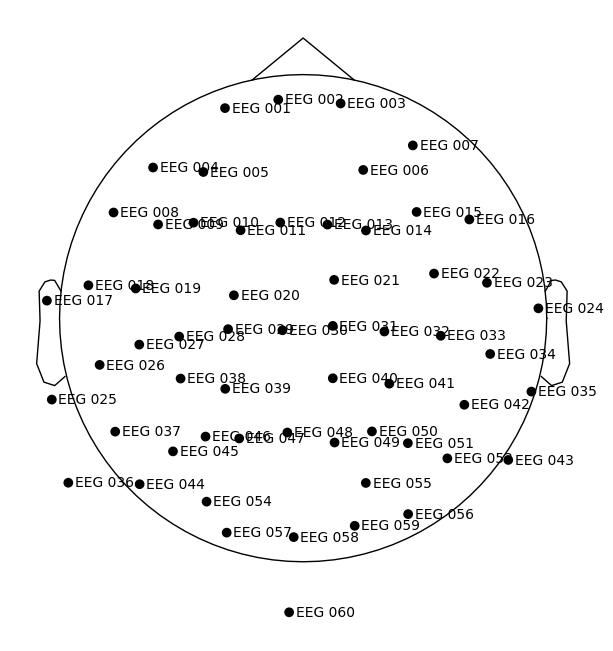

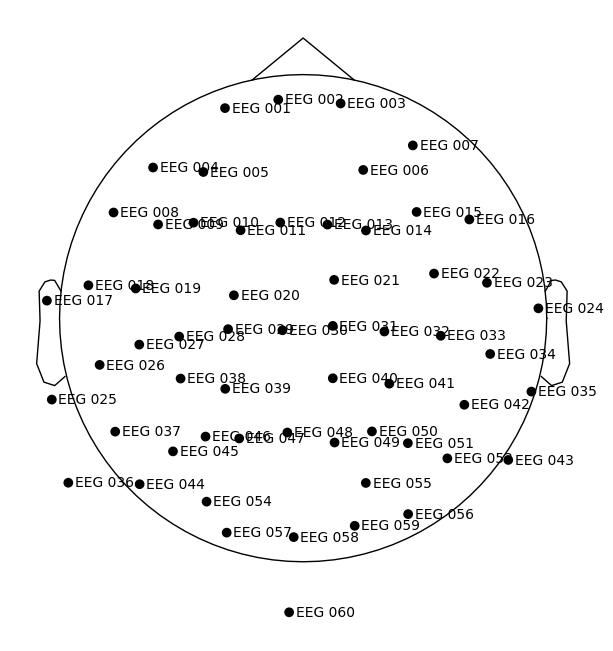

In [23]:
raw_eeg.plot_sensors(
    show_names=True,
    kind="topomap"
)

##EEG Data Matrix

In [24]:
print(raw_eeg)

<Raw | sample_audvis_raw.fif, 59 x 166800 (277.7 s), ~78.0 MiB, data loaded>


In [25]:
data, times = raw_eeg.get_data(
    return_times=True
)

print("Shape of EEG data:", data.shape)
print("Shape of time:", times.shape)

Shape of EEG data: (59, 166800)
Shape of time: (166800,)


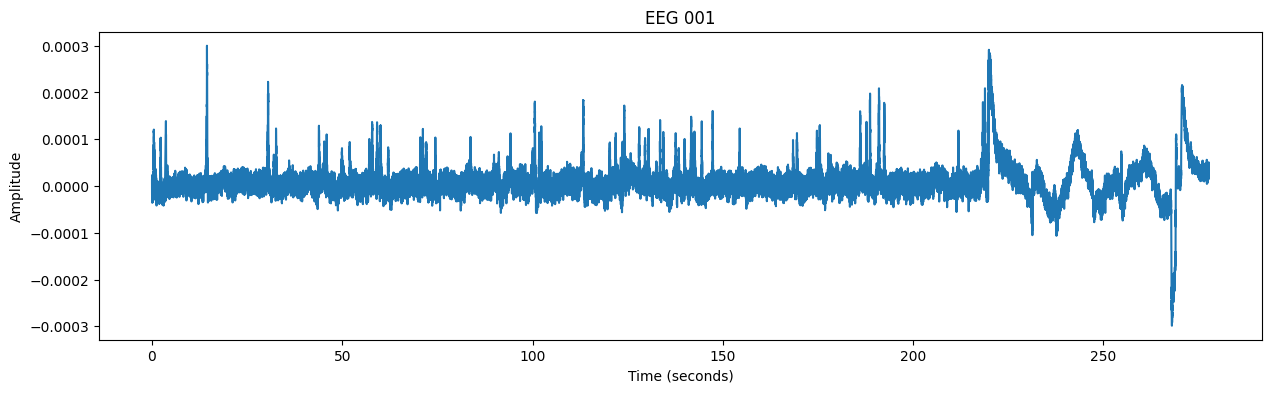

In [27]:
import matplotlib.pyplot as plt

channel = 0

plt.figure(figsize=(15,4))

plt.plot(
    times,
    data[channel]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(raw_eeg.ch_names[channel])

plt.show()

Using matplotlib as 2D backend.


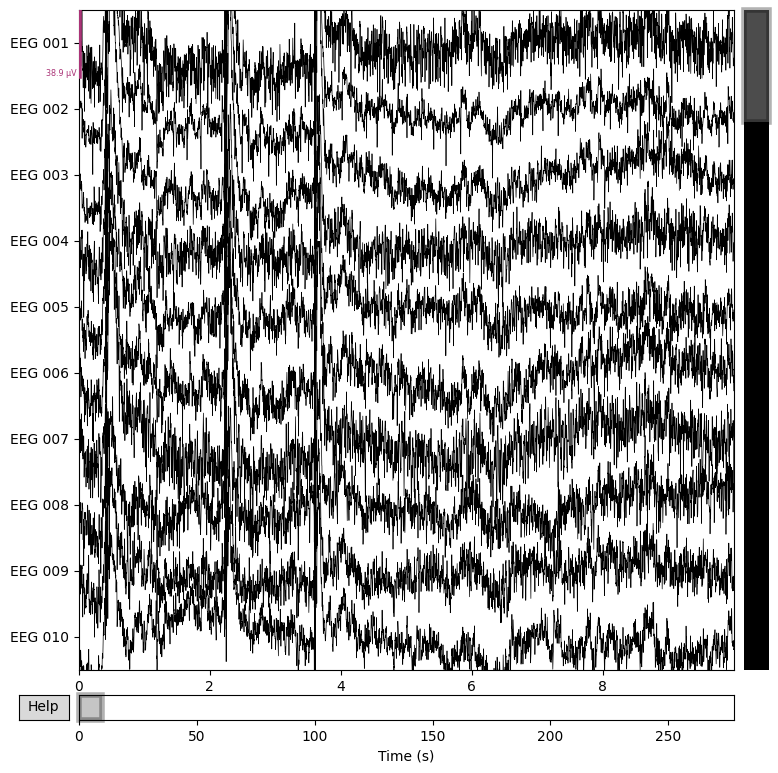

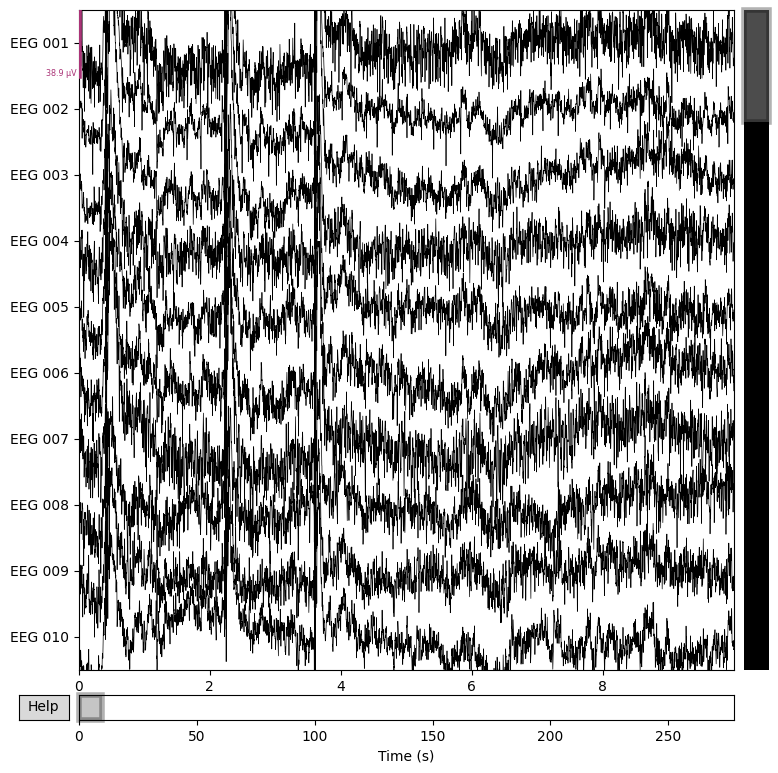

In [29]:
raw_eeg.plot(
    duration=10,
    n_channels=10,
    scalings="auto"
)

##EEG (Filtering)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edg

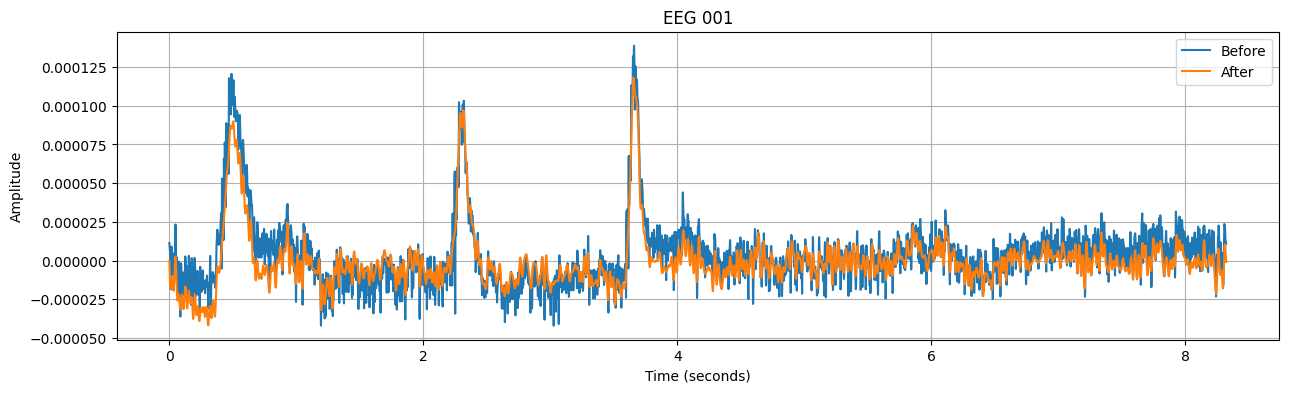

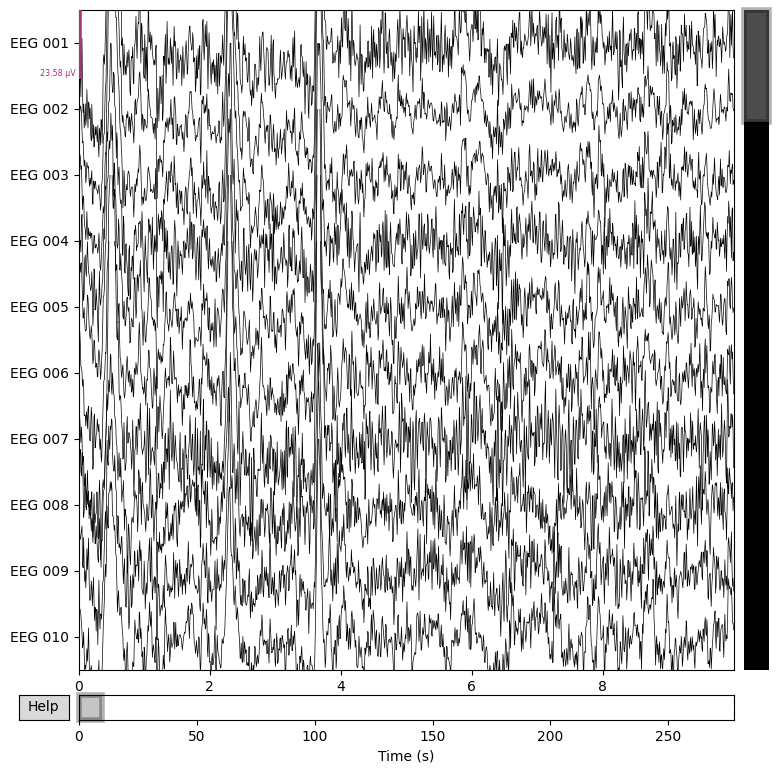

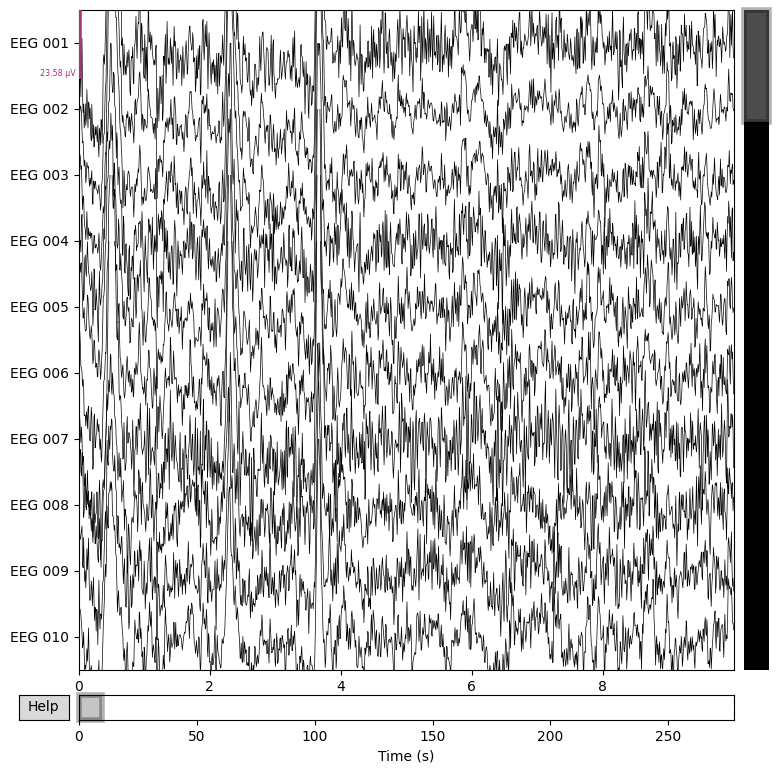

In [31]:
import mne
import matplotlib.pyplot as plt

raw_filtered = raw_eeg.copy()

raw_filtered.filter(
    l_freq=1,
    h_freq=40
)

raw_filtered.notch_filter(
    freqs=50
)

print(raw_filtered)

data_before, times = raw_eeg.get_data(
    return_times=True
)

data_after, _ = raw_filtered.get_data(
    return_times=True
)

channel = 0

plt.figure(figsize=(15,4))
plt.plot(
    times[:5000],
    data_before[channel][:5000],
    label="Before"
)

plt.plot(
    times[:5000],
    data_after[channel][:5000],
    label="After"
)

plt.title(raw_eeg.ch_names[channel])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

raw_filtered.plot(
    duration=10,
    n_channels=10,
    scalings="auto"
)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mne

raw_topo = raw_filtered.copy()

raw_topo.set_eeg_reference(
    "average"
)

eeg_data = raw_topo.get_data()

sfreq = raw_topo.info["sfreq"]

alpha_filtered = raw_topo.copy().filter(
    l_freq=8,
    h_freq=13
)

alpha_data = alpha_filtered.get_data()

alpha_power = np.mean(
    alpha_data ** 2,
    axis=1
)

evoked = mne.EvokedArray(
    alpha_power[:, np.newaxis],
    raw_topo.info,
    tmin=0
)

evoked.plot_topomap(
    times=0,
    ch_type="eeg",
    cmap="jet",
    contours=6,
    size=6
)

plt.show()

ModuleNotFoundError: No module named 'mne'